# Extração das Features em Tempo e Frequência

In [1]:
import os
import sys
# Add the parent directory to the Python path to allow module imports
sys.path.append(os.path.dirname(os.getcwd()))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

from modules.datasets import ICBHIAudioDataset, KAUHAudioDataset, CombinedFeaturesDataset
from modules.lungsound import LungSoundAudio
from modules.transforms import *

In [2]:
DATA_PATH = Path(os.path.join(os.path.dirname(os.getcwd()), "data"))
INTERIM_DATA_FOLDER = DATA_PATH / "interim"
PREPROCESSED_DATA_FOLDER = DATA_PATH / "preprocessed"

if not os.path.exists(INTERIM_DATA_FOLDER):
    raise FileNotFoundError(f"Interim data folder not found at {INTERIM_DATA_FOLDER}. Please run the interim preprocessing step first.")

if not os.path.exists(PREPROCESSED_DATA_FOLDER):
    os.makedirs(PREPROCESSED_DATA_FOLDER)
    print(f"Created preprocessed data folder at {PREPROCESSED_DATA_FOLDER}.")

## Preprocessed

In [ ]:
def save_features_as_npz(features: np.ndarray, sr: int, path: str):
    """
    Saves the extracted features and sampling rate to a .npz file.
    Args:
        features (np.ndarray): The extracted features to be saved.
        sr (int): The sampling rate associated with the features.
        path (str): The path where the features will be saved.
    """
    np.savez(path, features=features, sr=sr)

def preprocess_features(original_data_path: Path, preprocessed_data_path: Path, save_as: str = "npz"):
    """
    Preprocesses the original data and saves the preprocessed data to the specified location using multiple feature extractors.
    Args:
        original_data_path (Path): Path to the original raw data.
        preprocessed_data_path (Path): Path where the preprocessed data will be saved.
        save_as (str): Format to save the preprocessed data ('npy', 'npz', or 'png').
    """

    datasets = [
        ICBHIAudioDataset(original_data_path),
        KAUHAudioDataset(original_data_path)
    ]

    feature_extractors = {
        "MagSTFT": MagSTFT(),
        "ImagSTFT": ImagSTFT(),
        "RealSTFT": RealSTFT(),
        "Phase": Phase(),
        "MelSpectrogram": MelSpectrogram(n_mels=128),
        "MFCC": MFCC(n_mfcc=128),
        "MFCCDelta": MFCCDelta(n_mfcc=128),
        "Chroma": Chroma(n_chroma=128),
    }

    # Iterate through each dataset and apply preprocessing to the audio files
    for dataset in datasets:
        df = dataset.data
        for extractor_name, extractor in feature_extractors.items():
            for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"Preprocessing {dataset.name} with {extractor_name}"):
                file_path = dataset.root / row["FilePath"]
                diagnosis = row["Diagnosis"]
                # Load the audio file using the LungSound class
                audio = LungSoundAudio(file_path)
                # Apply feature extraction
                features = extractor(audio)

                # Construct the new file path for the preprocessed features
                new_file_name = f"{Path(file_path).stem}.{save_as}"
                preprocessed_file_path = preprocessed_data_path / dataset.name / extractor_name / diagnosis / new_file_name
                preprocessed_file_path.parent.mkdir(parents=True, exist_ok=True)

                # Save the preprocessed audio to the new location
                if save_as == "npz":
                    save_features_as_npz(features.features, features.sr, preprocessed_file_path)
                else:
                    raise ValueError(f"Unsupported save format: {save_as}")

            # Save the preprocessing parameters to a json file
            json_path = preprocessed_data_path / dataset.name / extractor_name / "features_preprocessing.json"
            feature_extractor = {
                extractor.__class__.__name__: {
                    "params": vars(extractor),
                    "plot_params": extractor.plot_params
                }
            }
            preprocessing = {
                "feature_extractor": feature_extractor,
            }
            with open(json_path, "w") as f:
                json.dump(preprocessing, f, indent=4, default=str)

        # Save the new data to a CSV file
        data_path = preprocessed_data_path / dataset.name / "metadata.csv"
        new_df = df.copy()
        new_df["FilePath"] = new_df["FilePath"].apply(lambda x: f"{Path(x).stem}.{save_as}")
        new_df.rename(columns={"FilePath": "FileName"}, inplace=True)
        new_df.to_csv(data_path, index=False)

    print("-------------------------------------------------------")
    print(f"Preprocessing for {original_data_path.name} completed.")
    print(f"Data saved to {os.path.relpath(preprocessed_data_path, start=os.getcwd())}")

In [ ]:
preprocess_features(INTERIM_DATA_FOLDER, PREPROCESSED_DATA_FOLDER, save_as="npz")

## Verificando a distribuição do Dataset

Combined dataset contains 5962 samples.


Diagnosis
COPD                3487
Healthy              828
Asthma               520
Pneumonia            355
Heart Failure        252
URTI                 159
Bronchiectasis       112
Bronchiolitis         91
Lung Fibrosis         57
Pleural Effusion      51
Bronchitis            36
LRTI                  14
Name: count, dtype: int64

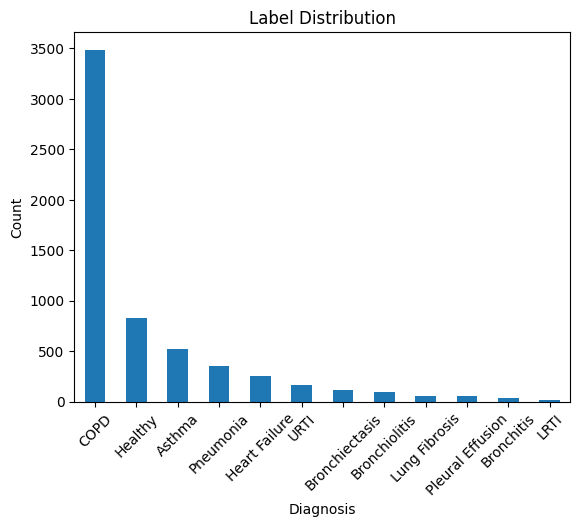

In [3]:
def plot_label_distribution(df):
    """
    Plot the distribution of labels in the dataset.
    Args:
        df (pd.DataFrame): The DataFrame containing label information.
    """
    label_counts = df["Diagnosis"].value_counts()
    display(label_counts)
    label_counts.plot(kind="bar")
    plt.title("Label Distribution")
    plt.xlabel("Diagnosis")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()
    
combined_dataset = CombinedFeaturesDataset(PREPROCESSED_DATA_FOLDER, "MagSTFT", split="all")
print(f"Combined dataset contains {len(combined_dataset)} samples.")

plot_label_distribution(combined_dataset.data)

Particionamento do dataset em treino, validação e teste. O número de amostras COPD foi limitado em 1000 (menos de 1/3 de sua quantidade total).

TRAIN DATASET
Combined train dataset contains 2425 samples.


Diagnosis
COPD              800
Healthy           658
Asthma            412
Pneumonia         257
URTI              125
Bronchiectasis     84
Bronchiolitis      56
Lung Fibrosis      33
Name: count, dtype: int64

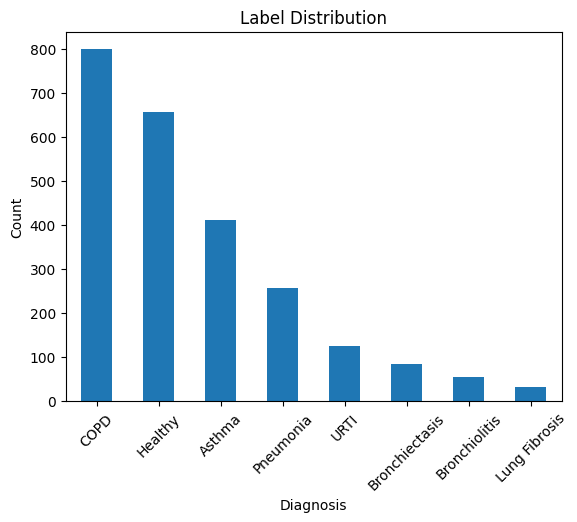

VALIDATION DATASET
Combined validation dataset contains 372 samples.


Diagnosis
COPD              100
Healthy            85
Pneumonia          63
Asthma             54
Bronchiolitis      21
URTI               20
Lung Fibrosis      15
Bronchiectasis     14
Name: count, dtype: int64

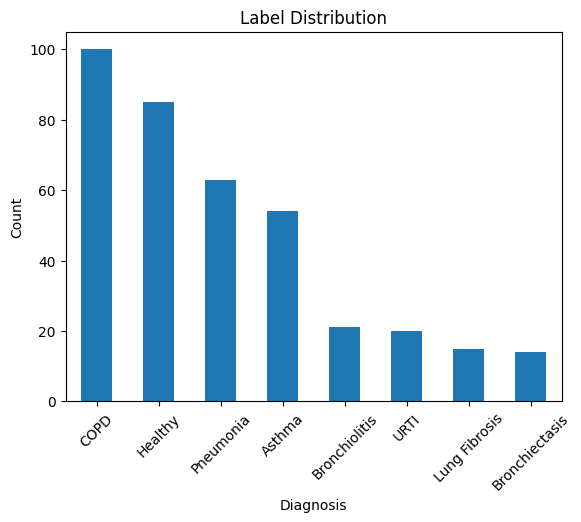

TEST DATASET
Combined test dataset contains 325 samples.


Diagnosis
COPD              100
Healthy            85
Asthma             54
Pneumonia          35
Bronchiectasis     14
Bronchiolitis      14
URTI               14
Lung Fibrosis       9
Name: count, dtype: int64

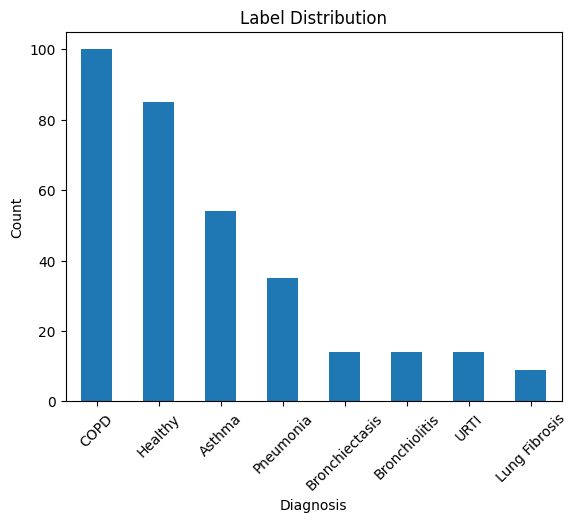

In [5]:
SELECTED_CLASSES = [
    "Asthma",
    "Bronchiectasis",
    "Bronchiolitis",
    "COPD",
    "Healthy",
    "Lung Fibrosis",
    "Pneumonia",
    "URTI",
]

combined_train_dataset = CombinedFeaturesDataset(PREPROCESSED_DATA_FOLDER, "MagSTFT", split="train", classes=SELECTED_CLASSES, sample_limit=1000)
print(f"{'='*20}\nTRAIN DATASET\n{'='*20}")
print(f"Combined train dataset contains {len(combined_train_dataset)} samples.")
plot_label_distribution(combined_train_dataset.data)

combined_val_dataset = CombinedFeaturesDataset(PREPROCESSED_DATA_FOLDER, "MagSTFT", split="val", classes=SELECTED_CLASSES, sample_limit=1000)
print(f"{'='*20}\nVALIDATION DATASET\n{'='*20}")
print(f"Combined validation dataset contains {len(combined_val_dataset)} samples.")
plot_label_distribution(combined_val_dataset.data)

combined_test_dataset = CombinedFeaturesDataset(PREPROCESSED_DATA_FOLDER, "MagSTFT", split="test", classes=SELECTED_CLASSES, sample_limit=1000)
print(f"{'='*20}\nTEST DATASET\n{'='*20}")
print(f"Combined test dataset contains {len(combined_test_dataset)} samples.")
plot_label_distribution(combined_test_dataset.data)